## 🗂️ Locations

**Reference:** [Location repositories](../reference/input_formats.md#location-repositories) **Network/Router API:** [🗂️ Locations](hi12_locations.ipynb)

In [1]:
import pprint

from prettyTables import Table

In [2]:
from optiwindnet.importer import load_repository
from optiwindnet.svg import svgplot

In [3]:
%config InlineBackend.figure_formats = ['svg']

[load_repository()](../autoapi/optiwindnet/importer/index.rst#optiwindnet.importer.load_repository) reads the `.osm.pbf` and `.yaml` locations distributed with **optiwindnet** into a _namedtuple_ of NetworkX graphs containing location data — see [Location repositories](../reference/input_formats.md#location-repositories).

Power declarations are loaded by default. Borssele, Trianel Windpark Borkum, and Walney Extension contain unequal ratings, so low-level solvers on those graphs require `capacity_nominal` and a compatible router. Use `load_repository(read_powers=False)` when capacities should count turbines, or follow [Mixed turbine power](lo16_mixed_power.ipynb) to retain nominal ratings.

In [4]:
locations = load_repository()

In [5]:
pprint.pp(sorted(locations._fields), compact=True)
print(f'Location count: {len(locations)}')

['albatros', 'amalia', 'amrumbank', 'anglia', 'anglia3', 'anholt', 'arkona',
 'baltic2', 'bard', 'beatrice', 'belwind', 'binhainorthH2', 'bodhi', 'borkum',
 'borkum2', 'borkum3', 'borssele', 'brieuc', 'bucht', 'butendiek',
 'cazzaro_2022', 'cazzaro_2022G140', 'cazzaro_2022G210', 'changhua1',
 'coastalva', 'dantysk', 'doggerA', 'doggerB', 'doggerC', 'dudgeon', 'eagle',
 'fecamp', 'gabbin', 'galloper', 'gangkou1', 'gangkou2', 'gemini1', 'gemini2',
 'glotech1', 'gode', 'gwynt', 'hedreiht', 'hohesee', 'horns', 'horns2',
 'horns3', 'hornsea', 'hornsea2', 'hornsea2w', 'humber', 'inchcape', 'jiaxing1',
 'kaskasi', 'kfA', 'kfB', 'kustnoord', 'kustzuid', 'lillgrund', 'lincs',
 'london', 'luchterduinen', 'meerwind', 'merkur', 'mermaid', 'morayeast',
 'moraywest', 'nanpeng', 'nazaire', 'neart', 'noirmoutier', 'nordsee',
 'nordseeost', 'norther', 'northwind', 'nysted', 'ormonde', 'race', 'rampion',
 'rental', 'revolution', 'riffgat', 'robin', 'rough', 'rudongH10', 'rudongH6',
 'rudongH8', 'rudongd

In [6]:
type(locations.sands)

networkx.classes.graph.Graph

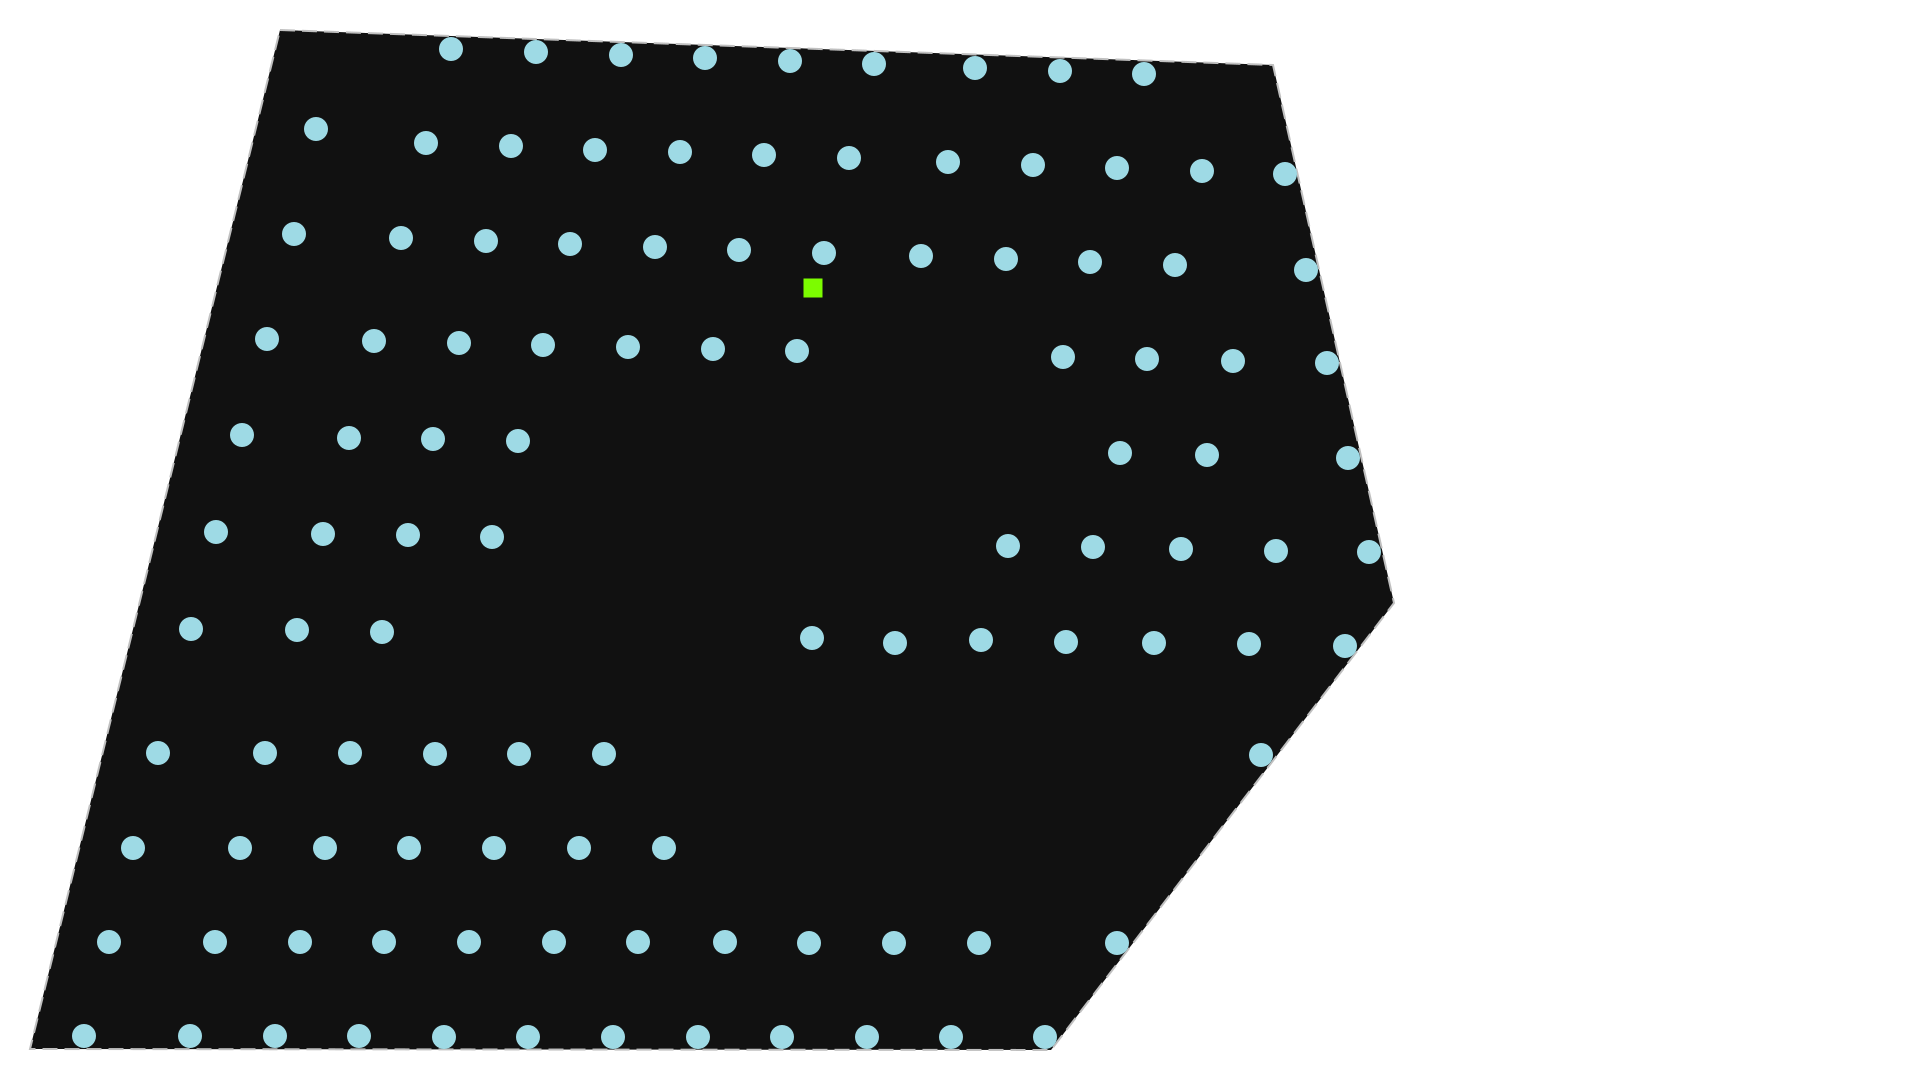

In [7]:
svgplot(locations.sands)

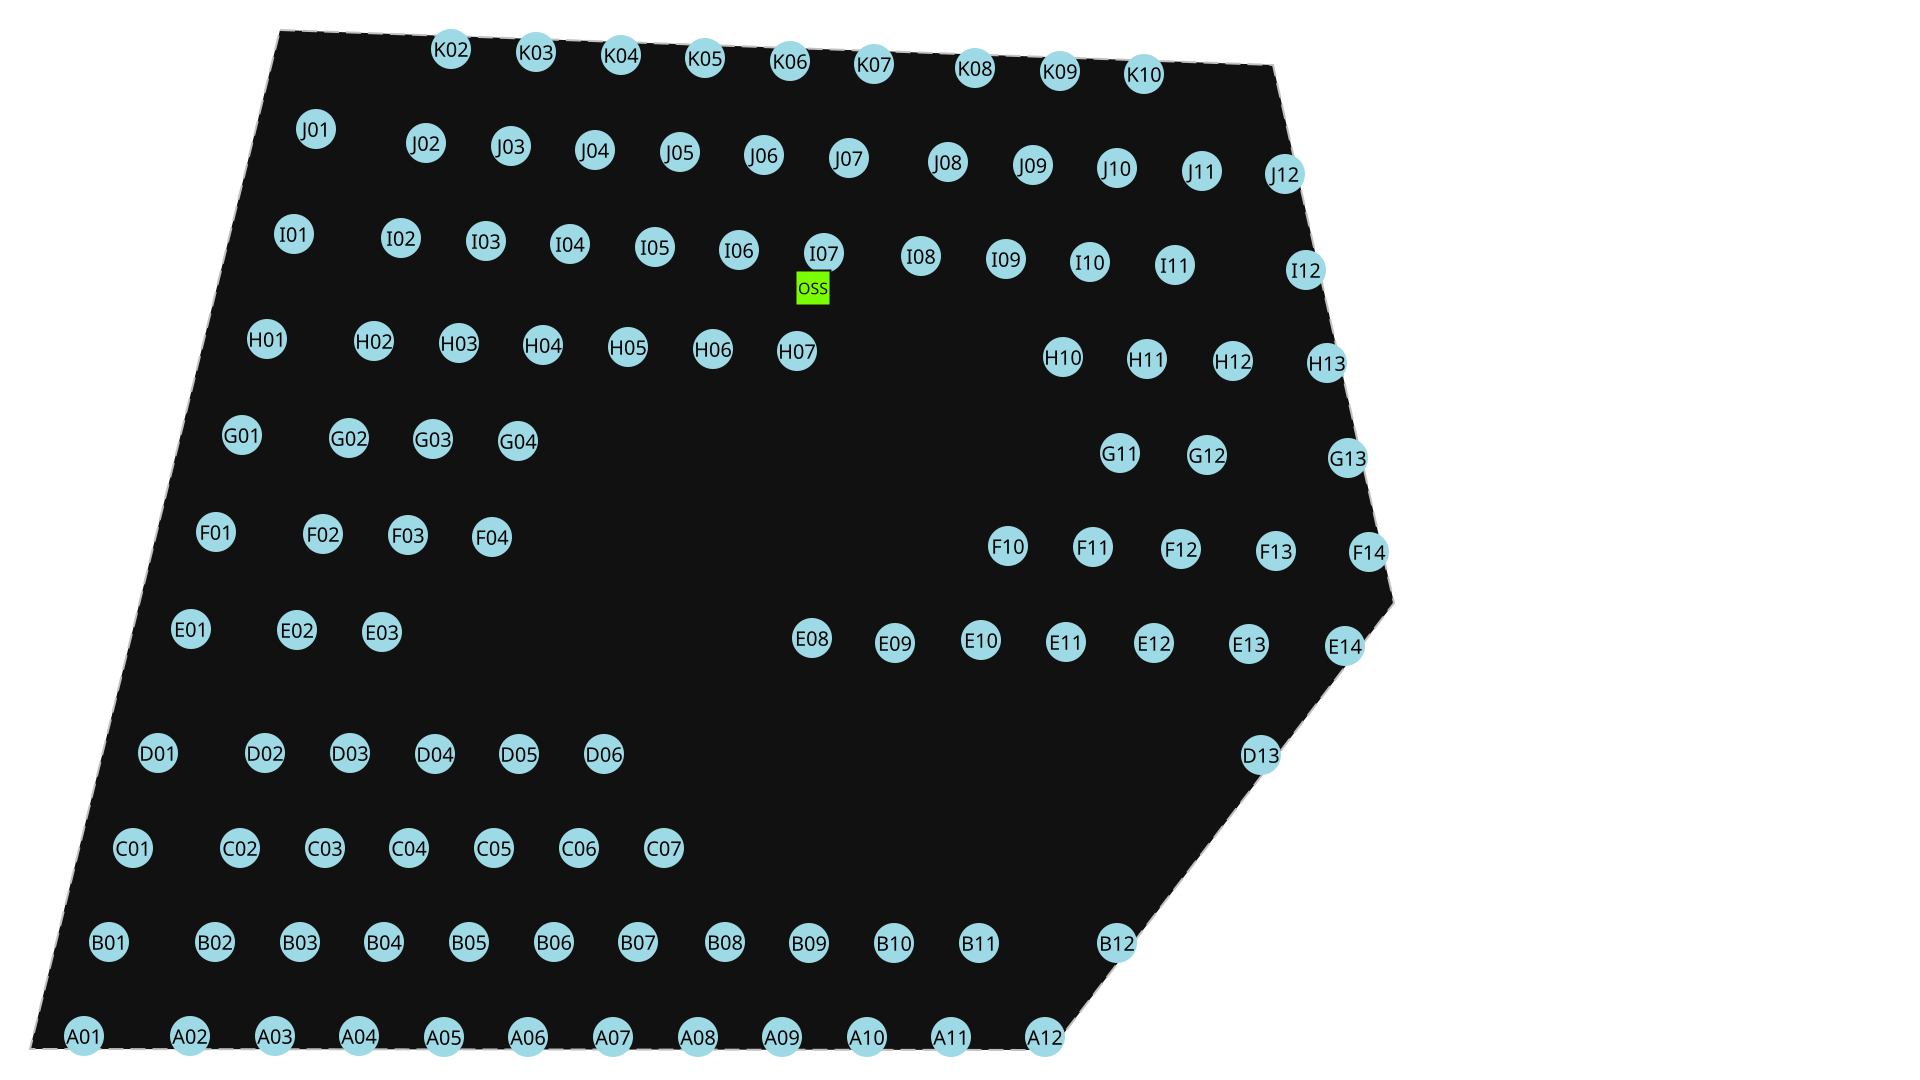

In [8]:
svgplot(locations.sands, node_tag='label')

In [9]:
rows = [
    (L.graph['name'], L.graph['handle'], L.graph['R'], L.graph['T'])
    for L in sorted(locations, key=lambda loc: loc.graph['name'])
]
Table(rows, headers=('name', 'handle', 'R', 'T'))

name,handle,R,T
Albatros,albatros,1,16
Amrumbank West,amrumbank,1,80
Anholt,anholt,1,111
Arkona,arkona,1,60
BARD Offshore 1,bard,1,80
Baltic 2,baltic2,1,80
Baltic Eagle,eagle,1,50
Beatrice,beatrice,2,84
Belwind,belwind,1,55
Borkum Riffgrund 1,borkum,1,78
